In [1]:
import yaml
import numpy as np
import polars as pl
import polars.selectors as cs
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Subset Olink RVAT significant
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/proteomics_prs_am_loftee_mac20_burden_regression_results.parquet -o /home/dnanexus/data_dir/olink/proteomics_prs_am_loftee_mac20_burden_regression_results.parquet
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/olink/blacklist/proteomics_prs_df_loftee_mac20_burden_regression_results.parquet -o /home/dnanexus/data_dir/proteomics_prs_df_loftee_mac20_burden_regression_results.parquet

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/olink_all_mac20_lofteeHC_correlations.parquet -o /home/dnanexus/data_dir/olink_all_mac20_lofteeHC_correlations.parquet

olink_whitelist = (
    pl.read_parquet('/home/dnanexus/data_dir/proteomics_prs_loftee_mac20_burden_regression_results.parquet')
    .rename({'gene': 'region'})
    .filter((pl.col('padj')<=0.05) & (pl.col('wilcox_padj')<=0.05) )
    .select(['region'])
    .with_columns(
        phenotype = pl.col('region') + '_olink'
    )
)

olink_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/olink_all_mac20_lofteeHC_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .drop_nans()
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

olink_whitelist = (
    olink_whitelist
    .join(olink_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    # .sort('loftee_corr_abs', descending=True)
    # .sort('pval_fdr')
    # .unique(subset=["region"], keep="first", maintain_order=True)
)

olink_whitelist

Error: path "/home/dnanexus/data_dir/proteomics_prs_df_loftee_mac20_burden_reg
ression_results.parquet" already exists but -f/--overwrite was not set
Error: path
"/home/dnanexus/data_dir/olink_all_mac20_lofteeHC_correlations.parquet"
already exists but -f/--overwrite was not set


region,phenotype,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64
"""ENSG00000163606""","""ENSG00000163606_olink""",0.204082,0.204082,1.0
"""ENSG00000144857""","""ENSG00000144857_olink""",0.162616,0.162616,1.0
"""ENSG00000161270""","""ENSG00000161270_olink""",0.175562,0.175562,1.0
"""ENSG00000091129""","""ENSG00000091129_olink""",0.165924,0.165924,1.0
"""ENSG00000132437""","""ENSG00000132437_olink""",0.214824,0.214824,1.0
…,…,…,…,…
"""ENSG00000101160""","""ENSG00000101160_olink""",0.386419,0.386419,1.0
"""ENSG00000130528""","""ENSG00000130528_olink""",0.305544,0.305544,1.0
"""ENSG00000110448""","""ENSG00000110448_olink""",0.337765,0.337765,1.0


In [3]:
# Configuration and paths
mac = 20
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# abs_phenotypes = True
abs_phenotypes = False
extreme_pheno_dir = 'Bottom'

# Load annotation configuration
if abs_phenotypes:
    config_path = "/home/dnanexus/ukbgym/config_odds.yaml" # If abs_pheno then deleteriousness direction
else:    
    config_path = "/home/dnanexus/ukbgym/config_olink_odds.yaml"

with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""plof""","""loftee_hc""","""#DD4344""","""LOFTEE HC""",-1
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",-1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",-1
"""missense""","""score_pai3d""","""#feb72d""","""PrimateAI-3D""",-1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",1
…,…,…,…,…
"""regulatory""","""promoterai""","""#00A99D""","""PromoterAI""",1
"""regulatory""","""fz_blood_mean""","""crimson""","""Flashzoi mean across RNA blood""",1
"""regulatory""","""fz_all_mean""","""#FFA500""","""Flashzoi mean across RNA all""",1


In [4]:
new_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/flashzoi_scores"
new_anno_filename = "TSS_flashzoi_EURunrelated_variants_burden_test_olink_genes_GENCODEv40_ukbbgym.parquet"
!dx download {new_anno_path}/{new_anno_filename} -o /home/dnanexus/data_dir/

new_anno_local = f'/home/dnanexus/data_dir/{new_anno_filename}'

new_anno_df = (
    pl.read_parquet(new_anno_local)
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .with_columns(
        fz_all_mean = pl.mean_horizontal(cs.starts_with('RNA:').abs()),
        fz_blood_mean = pl.mean_horizontal(pl.col(['RNA:blood_7531', 'RNA:blood_7532', 'RNA:blood_7533']).abs()),
    )
    .select(['id', 'region', 'fz_blood_mean', 'fz_all_mean'])
    .lazy()
)

new_anno_df.head().collect()

Error: path "/home/dnanexus/data_dir/TSS_flashzoi_EURunrelated_variants_burden
_test_olink_genes_GENCODEv40_ukbbgym.parquet" already exists but
-f/--overwrite was not set


/tmp/ipykernel_599032/3855157914.py:9: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,fz_blood_mean,fz_all_mean
str,str,f32,f32
"""chr1:1019650:G:A""","""ENSG00000188157""",0.031861,0.014385
"""chr1:1019763:A:T""","""ENSG00000188157""",0.011518,0.008107
"""chr1:1019639:G:A""","""ENSG00000188157""",0.011454,0.010896
"""chr1:1019620:G:A""","""ENSG00000188157""",0.093067,0.036963
"""chr1:1019690:C:G""","""ENSG00000188157""",0.031027,0.014117


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

min_range = -500
max_range = +500

# Join new annotation if specified above
if new_anno_local is not None:
    anno = (
        anno
        .join(
            new_anno_df,
            on=['id', 'region'],
            how='left'
        )
    )

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .filter(
        # Olink whitelist
        (pl.col('region').is_in(olink_whitelist['region'].unique())) &
        
        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True) &
        # ((pl.col('vep_cds_relaxed')==True) | (pl.col('mane_cds')==True)) &
        # (pl.col('non_mane_cds')==False) &

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)) &

        # Core promoter
        (pl.col('promoterai_is_na') == False) &

        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True) &
        # (pl.col('consequence_synonymous_variant') == True) &
        # (pl.col('consequence_5_prime_utr_variant') == True) &
        # (pl.col('consequence_upstream_gene_variant') == True) &
        # (pl.col('consequence_downstream_gene_variant') == True) &
        # (pl.col('consequence_intron_variant') == True) &

        # Choose protein domain
        # (pl.col('ted_domain') == True) &
        # (pl.col('mobi_curated_disorder_priority') == True) &
        # (pl.col('mobi_lip_full') == True) &
        # (pl.col('low_complexity_domain') == True) &

        # Choose regulatory region
        # (pl.col('not_in_encode') == False) &
        # (pl.col('encode_eh_pr') == True) &
        # (pl.col('encode_all_tf') == True) &

        # Proximity to TSS
        # (pl.col('dist_to_tss') >= min_range) &
        # (pl.col('dist_to_tss') <= max_range) &

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    .with_columns(
        promoterai_abs = pl.col('promoterai').abs(),
    )
)

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]
fillna_cols = [c+'_is_na' for c in existing_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(existing_annos))
    )
    .collect(engine='streaming')
)


anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_599032/56534916.py:74: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_599032/56534916.py:82: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


promoterai_abs,loftee_hc,cadd_raw,region,absplice_dna_max,score_pai3d,verphylop,absplice2_max,promoterai,am_pathogenicity,esmscoremissense,delta_score,fz_all_mean,pangolin_score,abexp_abs_max,fz_blood_mean,id,gpn_score
f32,i8,f32,str,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,f32,str,f32
0.0109,0,-0.102138,"""ENSG00000181374""",0.003,0.0,-1.198,0.000356,0.0109,0.0,0.0,0.0,null,0.0,0.031551,null,"""chr17:34357647:A:T""",-0.98
0.0026,0,-0.298951,"""ENSG00000185359""",0.003,0.0,-4.587,0.000428,0.0026,0.0,0.0,0.0,null,0.0,0.181591,null,"""chr17:81695085:G:A""",0.34
0.0471,0,0.3453,"""ENSG00000172382""",0.0,0.0,0.499,0.0,0.0471,0.0,0.0,0.0,null,0.0,0.002372,null,"""chr16:2720632:C:A""",-1.4
0.0265,0,0.333435,"""ENSG00000105220""",0.0,0.0,-0.54,0.0,0.0265,0.0,0.0,0.0,null,0.0,0.003333,null,"""chr19:34359217:C:T""",-0.78
0.012,0,0.068814,"""ENSG00000100473""",0.001,0.0,-0.156,0.000033,-0.012,0.0,0.0,0.0,null,0.0,0.006871,null,"""chr14:30880206:C:A""",-2.27
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0754,0,0.123379,"""ENSG00000151882""",0.064,0.0,-1.042,0.014896,-0.0754,0.0,0.0,0.12,null,0.03,0.278886,null,"""chr5:43397035:C:T""",0.06
0.0062,0,0.477911,"""ENSG00000160867""",0.003,0.0,-3.288,0.000437,0.0062,0.0,0.0,0.0,null,0.01,0.018638,null,"""chr5:177086961:T:A""",-0.6
0.0108,0,0.80727,"""ENSG00000104763""",0.003,0.0,1.06,0.001173,-0.0108,0.0,0.0,0.0,null,0.24,0.060128,null,"""chr8:18084539:G:A""",-1.44


In [6]:
anno_fillna = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")
fillna_cols = set([c+'_is_na' for c in existing_annos]).intersection(set(anno_fillna.collect_schema().names()))

anno_fillna_melted = (
    anno_fillna
    .filter(pl.col('region').is_in(olink_whitelist['region'].unique()))
    .select(['id', 'region'] + list(fillna_cols))
    .join(
        anno.select(['id', 'region']).lazy(), 
        on=['id', 'region'], 
        how='semi'
    )
    .unpivot(
        index=["id", "region"],
        on=list(fillna_cols),
        variable_name="annotation",
        value_name="annotation_is_na"
    )
    .filter(
        pl.col('annotation_is_na') == 1
    )
    .with_columns(
        annotation = pl.col('annotation').str.replace('_is_na$', '')
    )
    # .collect(engine='streaming')
)

anno_fillna_melted.head().collect()

/tmp/ipykernel_599032/3727860496.py:28: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_is_na
str,str,str,i8
"""chr22:40855069:C:G""","""ENSG00000100380""","""esmscoremissense""",1
"""chr9:128128307:C:T""","""ENSG00000148334""","""esmscoremissense""",1
"""chr4:101813689:A:T""","""ENSG00000153064""","""esmscoremissense""",1
"""chr1:174800231:G:A""","""ENSG00000152061""","""esmscoremissense""",1
"""chr11:130448524:G:A""","""ENSG00000166106""","""esmscoremissense""",1


In [7]:
# selected_categories = ['missense', 'genetic_diversity', 'conservation', 'regulatory_nondir'] # CDS
# selected_categories = ['missense', 'genetic_diversity', 'conservation'] # missense
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['genetic_diversity', 'conservation', 'naive']    # plof comparison
selected_categories = ['genetic_diversity', 'splicing', 'conservation', 'regulatory', 'regulatory_nondir'] # non coding
# selected_categories = ['genetic_diversity', 'splicing', 'conservation'] # introns

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )

    # Merge with annotation configuration to get direction and filter
    .join(
        anno_config_df.select(["annotation", "category", "annotation_dir"]).lazy(),
        on="annotation",
        how="left"
    )
    .filter(pl.col('category').is_in(selected_categories))
    .unique()

    # Remove null annotation scores
    .drop_nulls('annotation_score')

    # Correct scores by annotation direction
    .with_columns(
        annotation_score_dircor = pl.col('annotation_score') * pl.col("annotation_dir").cast(pl.Float32)
    )
    
    # Implement filtering based on the defined percentile
    .with_columns(
        annotation_score_dircor_rank_desc = pl.col('annotation_score_dircor').rank(method="max", descending=True).over(["annotation"]).cast(pl.Float32)
    )
    .drop(['annotation_score_dircor'])

    # Keep variants that don't have fillna annotation
    .join(
        anno_fillna_melted,
        on=['id', 'region', 'annotation'],
        how='anti'
    )

    .collect(engine='streaming')
)

melted_anno

/tmp/ipykernel_599032/3379193799.py:60: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


id,region,annotation,annotation_score,category,annotation_dir,annotation_score_dircor_rank_desc
str,str,str,f32,str,i8,f32
"""chr3:124848618:A:C""","""ENSG00000082781""","""promoterai_abs""",0.0156,"""regulatory_nondir""",-1,263010.0
"""chr3:124848063:G:C""","""ENSG00000082781""","""promoterai_abs""",0.0092,"""regulatory_nondir""",-1,173421.0
"""chr7:154051924:C:G""","""ENSG00000130226""","""promoterai_abs""",0.0079,"""regulatory_nondir""",-1,151578.0
"""chr8:17246648:T:G""","""ENSG00000155975""","""promoterai_abs""",0.3746,"""regulatory_nondir""",-1,665881.0
"""chr5:176542098:C:T""","""ENSG00000074276""","""promoterai_abs""",0.0224,"""regulatory_nondir""",-1,333999.0
…,…,…,…,…,…,…
"""chr10:73910982:T:C""","""ENSG00000122861""","""promoterai_abs""",0.0704,"""regulatory_nondir""",-1,544205.0
"""chr1:120100816:C:T""","""ENSG00000134250""","""promoterai_abs""",0.0605,"""regulatory_nondir""",-1,521326.0
"""chr11:77841078:G:A""","""ENSG00000087884""","""promoterai_abs""",0.0177,"""regulatory_nondir""",-1,287179.0


## Odds ratio computation

In [12]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus"

# APPV_FILE = "olink_cov_pcs_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet"
# APPV_FILE = "olink_protrider_prs_rint_all_genes_EURunrelated_appv_percentiles.parquet"
APPV_FILE = "cauc_protrider_lite_prs_t_df_all_genes_EURunrelated_appv_percentiles.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
olink_appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Merge phenotype data and annotation data
olink_appv = (
    olink_appv
    .filter(
        (pl.col('n_individuals') <= mac)
    )
    .filter(
        pl.col('region') + '_olink' == pl.col('phenotype')
    )
    .with_columns(
        mean_pheno_value = pl.when(abs_phenotypes)
            .then(pl.col('mean_pheno_value').abs())
            .otherwise(pl.col('mean_pheno_value')),
        mean_pheno_value_ptile = pl.when(extreme_pheno_dir.lower() == 'bottom')
            .then(1 - pl.col('mean_pheno_value_ptile'))
            .otherwise(pl.col('mean_pheno_value_ptile')),
    )
)

Error: path "/home/dnanexus/cauc_protrider_lite_prs_t_df_all_genes_EURunrelate
d_appv_percentiles.parquet" already exists but -f/--overwrite was not set


## Odds ratio computation

In [13]:
n_steps = 101
min_rank_cutoff = 1_00
max_rank_cutoff = 1_000_000
max_rank_cutoff = np.min([max_rank_cutoff, anno.shape[0]])
or_threshold_pheno = 0.9

# We assume that all models score the same number of variants (all the variants in 'anno')
log_steps = np.geomspace(min_rank_cutoff, max_rank_cutoff, n_steps)

cutoffs_lazy = pl.LazyFrame({"rank_cutoff": log_steps.astype(int)})

cutoffs_lazy.collect()

rank_cutoff
i64
100
109
119
130
142
…
493799
539541
589521


In [14]:
# --- Build main query (same as before, but stop before group_by) ---
or_lazy = (
    olink_appv
    .join(
        olink_whitelist.lazy(),
        on=["region", "phenotype"],
        how="semi"
    )
    .join(
        melted_anno.lazy(), 
        on="id", 
        how="inner"
    )

    # Cross join with cutoffs and compute odds ratios
    .join(
        cutoffs_lazy, 
        how="cross"
    )
    .group_by(["annotation", "region", "phenotype", "rank_cutoff"])
    .agg(
        n_dis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) & 
            (pl.col("mean_pheno_value_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_above_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") <= pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") < or_threshold_pheno)
        ).sum(),
        n_dis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") >= or_threshold_pheno)
        ).sum(),
        n_notdis_below_cutoff = (
            (pl.col("annotation_score_dircor_rank_desc") > pl.col("rank_cutoff")) &
            (pl.col("mean_pheno_value_ptile") < or_threshold_pheno)
        ).sum()
    )
    .with_columns(
        odds_ratio = (pl.col("n_dis_above_cutoff") / pl.col("n_notdis_above_cutoff")) / (pl.col("n_dis_below_cutoff") / pl.col("n_notdis_below_cutoff"))
    )
)

# Execute
print("Executing with odds ratios...")
or_df = or_lazy.collect(engine='streaming').sort('rank_cutoff', descending=True)

or_df

Executing with odds ratios...


annotation,region,phenotype,rank_cutoff,n_dis_above_cutoff,n_notdis_above_cutoff,n_dis_below_cutoff,n_notdis_below_cutoff,odds_ratio
str,str,str,i64,u64,u64,u64,u64,f64
"""fz_all_mean""","""ENSG00000143126""","""ENSG00000143126_olink""",703799,0,6,0,0,NaN
"""absplice_dna_max""","""ENSG00000101160""","""ENSG00000101160_olink""",703799,12,58,0,0,NaN
"""promoterai""","""ENSG00000144649""","""ENSG00000144649_olink""",703799,6,108,0,0,NaN
"""promoterai_abs""","""ENSG00000116815""","""ENSG00000116815_olink""",703799,32,130,0,0,NaN
"""delta_score""","""ENSG00000173702""","""ENSG00000173702_olink""",703799,4,35,0,0,NaN
…,…,…,…,…,…,…,…,…
"""fz_blood_mean""","""ENSG00000167114""","""ENSG00000167114_olink""",100,0,0,0,6,NaN
"""promoterai_abs""","""ENSG00000136943""","""ENSG00000136943_olink""",100,0,0,53,247,NaN
"""cadd_raw""","""ENSG00000104529""","""ENSG00000104529_olink""",100,0,0,111,874,NaN


## Plotting

In [16]:
# or_df = pl.read_parquet(f'/home/dnanexus/data_dir/results/odds_ratio_all_vars_{or_threshold_pheno}_wgs_EUR_genebass1e6_maf1e3.parquet')

print('unique percentile cutoffs:', or_df['rank_cutoff'].n_unique())

plt_df = (
    or_df
    .drop_nans()
    .filter(pl.col("odds_ratio").is_finite())
    .with_columns(
        n_gene_phenos = pl.len().over(['rank_cutoff', 'annotation']),
        log_rank_cutoff = np.log10(pl.col('rank_cutoff')),
        log_rank_cutoff_inv = np.log10(1/pl.col('rank_cutoff')),
    )
    .with_columns(
        # log_rank_cutoff_inv = (np.log10(min_rank_cutoff) + np.log10(max_rank_cutoff)) - pl.col('log_rank_cutoff'),
        med_odds_ratio = pl.col('odds_ratio').median().over(['rank_cutoff', 'annotation']),
        avg_odds_ratio = pl.col('odds_ratio').mean().over(['rank_cutoff', 'annotation']),
        se_odds_ratio = pl.col('odds_ratio').std().over(['rank_cutoff', 'annotation'])/(pl.col('n_gene_phenos').sqrt()),
    )
    .with_columns(
        std_ci_upper = pl.col('avg_odds_ratio') + 1.96 * (pl.col('se_odds_ratio')),
        std_ci_lower = pl.col('avg_odds_ratio') - 1.96 * (pl.col('se_odds_ratio')),
    )
    .select(['annotation', 'log_rank_cutoff', 'rank_cutoff', 'log_rank_cutoff_inv', 'n_gene_phenos', 'med_odds_ratio', 'avg_odds_ratio', 'se_odds_ratio', 'std_ci_upper', 'std_ci_lower'])
    .unique()
    .join(
        anno_config_df.select(['annotation', 'color', 'label', 'category']),
        on='annotation',
        how='left'
    )
    .sort('log_rank_cutoff')
    
    # Remove data points without ci or with or=0
    .filter(
        (pl.col('std_ci_upper').is_not_null()) &
        (pl.col('std_ci_lower').is_not_null()) &
        (pl.col('n_gene_phenos') >= 20) &
        (pl.col('avg_odds_ratio') > 0) &
        (pl.col('std_ci_lower') > 0)
    )
)

plt_df

unique percentile cutoffs: 101


annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""verphylop""",2.460898,289,-2.460898,64,0.0,0.368546,0.176971,0.715408,0.021683,"""#942c80""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.499687,316,-2.499687,71,0.0,0.33221,0.159938,0.645689,0.018732,"""#942c80""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.537819,345,-2.537819,74,0.0,0.318742,0.153601,0.619801,0.017684,"""#942c80""","""Vertebrate PhyloP""","""conservation"""
"""gpn_score""",2.576341,377,-2.576341,104,0.0,0.285245,0.141751,0.563077,0.007413,"""#942c80""","""GPN-MSA""","""conservation"""
"""verphylop""",2.576341,377,-2.576341,82,0.0,0.317908,0.141421,0.595093,0.040722,"""#942c80""","""Vertebrate PhyloP""","""conservation"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""gpn_score""",5.808974,644130,-5.808974,760,0.192883,0.30303,0.013274,0.329048,0.277013,"""#942c80""","""GPN-MSA""","""conservation"""
"""abexp_abs_max""",5.808974,644130,-5.808974,823,0.246593,0.380982,0.01527,0.41091,0.351053,"""#80CBC4""","""AbExp abs max""","""regulatory_nondir"""
"""verphylop""",5.808974,644130,-5.808974,748,0.209961,0.330127,0.013461,0.356512,0.303743,"""#942c80""","""Vertebrate PhyloP""","""conservation"""


/home/dnanexus/deeprvat2-env/lib/python3.11/site-packages/plotnine/geoms/annotation_logticks.py:97: PlotnineWarning: annotation_logticks for x-axis which does not have a log scale. The logticks may not make sense.


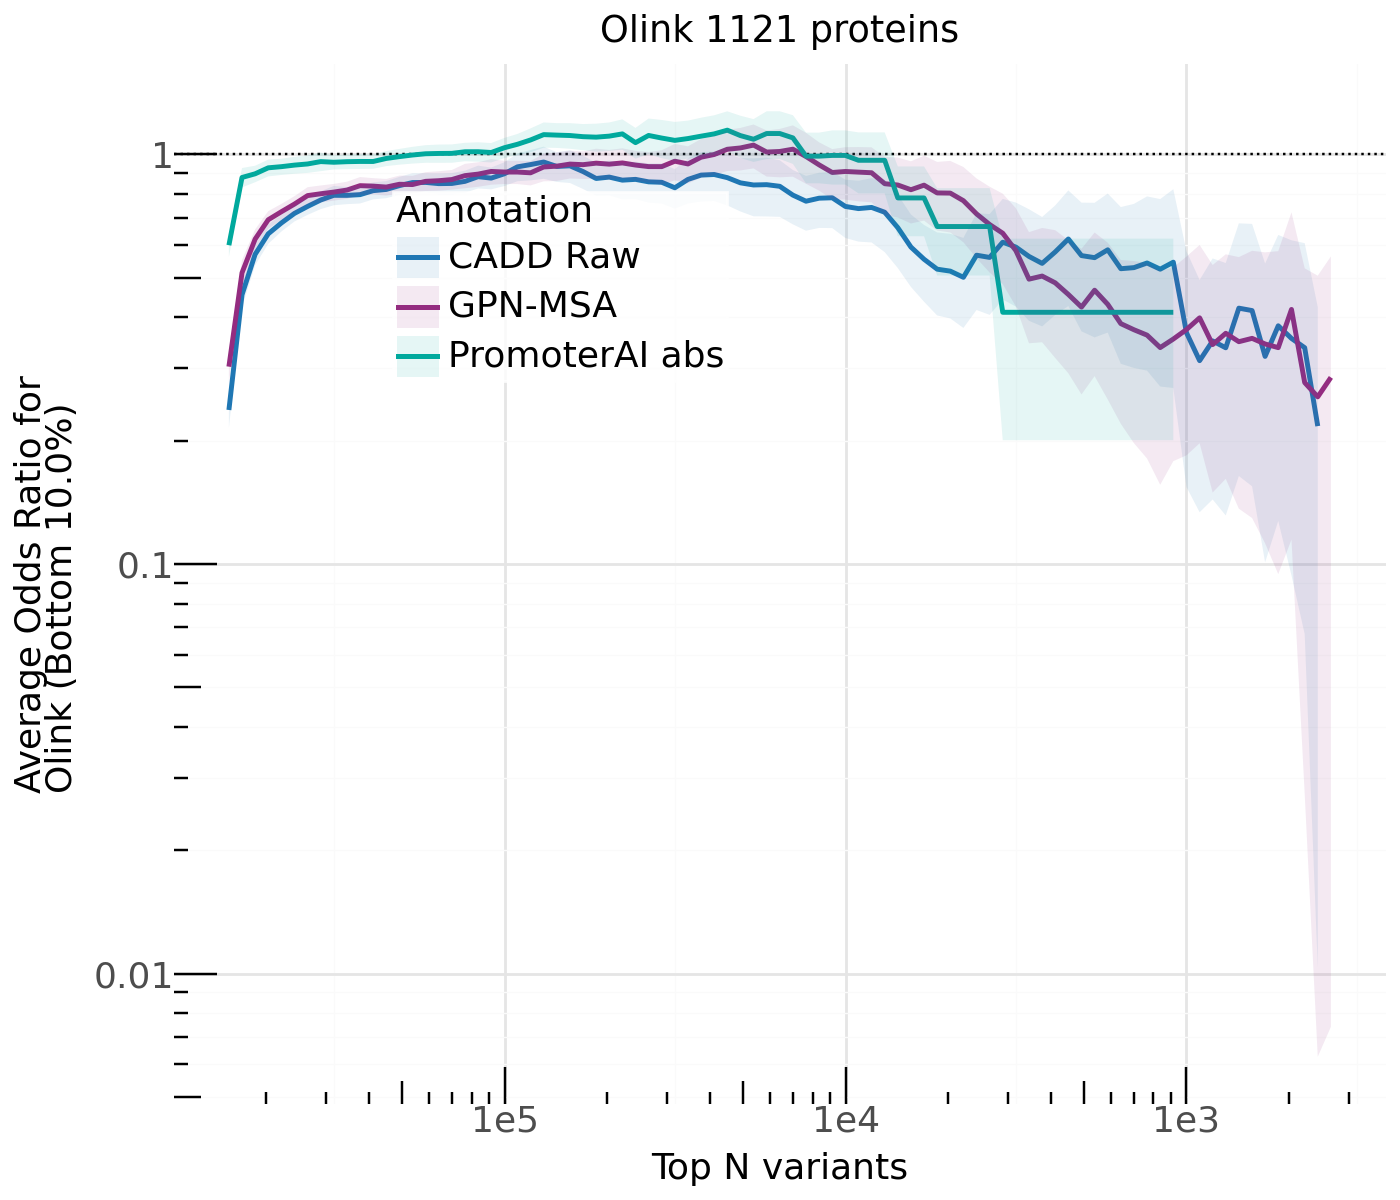

In [17]:
plot_df = (
    plt_df
    .filter(
        # (pl.col('log_rank_cutoff_inv') <= -4) &

        # (pl.col('annotation').is_in(['am_pathogenicity', 'score_pai3d', 'esmscoremissense']))
        # (pl.col('annotation').is_in(['am_pathogenicity', 'gpn_score', 'cadd_raw', 'abexp_abs_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'pangolin_score', 'delta_score', 'absplice2_max']))
        # (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs', 'fz_RNA_blood_abs_max', 'fz_RNA_all_abs_max']))
        (pl.col('annotation').is_in(['gpn_score', 'cadd_raw', 'promoterai_abs']))
    )
)

# Generate breaks and labels for x-axis
start_exp = int(np.log10(1/max_rank_cutoff))
end_exp = int(np.log10(1/min_rank_cutoff))
breaks_linear = np.arange(start_exp, end_exp + 1)
labels_sci = [f"1e{-b}" for b in breaks_linear]

color_dict = dict(zip(plt_df['label'], plt_df['color']))
pheno_label = round((1 - or_threshold_pheno) * 100, 1)

(
    ggplot(
        plot_df,
        aes(x='log_rank_cutoff_inv', y='avg_odds_ratio')
    )
    + geom_hline(aes(yintercept=1), color='black', linetype='dotted')
    + geom_line(aes(color='label'), size=1)
    + geom_ribbon(aes(ymin='std_ci_lower', ymax='std_ci_upper', fill='label'), alpha=0.1)
    + scale_fill_manual(values=color_dict)
    + scale_color_manual(values=color_dict)
    + labs(
        title=f"Olink {plt_df['n_gene_phenos'].max()} proteins",
        y=f"Average Odds Ratio for\nOlink ({extreme_pheno_dir} {pheno_label}%)",
        x="Top N variants",
        color="Annotation",
        fill="Annotation",
    )
    + scale_x_continuous(
        breaks=breaks_linear,
        labels=labels_sci
    )
    + scale_y_log10()
    # + lims(y=(-0.1, 3.5))
    + annotation_logticks(sides="lb")
    + theme_minimal()
    + theme(
        figure_size=(7, 6),
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        legend_position=(0.25, 0.85), 
        legend_background=element_rect(fill="white", color='white', alpha=0.8),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [18]:
plt_df.head()

annotation,log_rank_cutoff,rank_cutoff,log_rank_cutoff_inv,n_gene_phenos,med_odds_ratio,avg_odds_ratio,se_odds_ratio,std_ci_upper,std_ci_lower,color,label,category
str,f64,i64,f64,u64,f64,f64,f64,f64,f64,str,str,str
"""verphylop""",2.460898,289,-2.460898,64,0.0,0.368546,0.176971,0.715408,0.021683,"""#942c80""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.499687,316,-2.499687,71,0.0,0.33221,0.159938,0.645689,0.018732,"""#942c80""","""Vertebrate PhyloP""","""conservation"""
"""verphylop""",2.537819,345,-2.537819,74,0.0,0.318742,0.153601,0.619801,0.017684,"""#942c80""","""Vertebrate PhyloP""","""conservation"""
"""gpn_score""",2.576341,377,-2.576341,104,0.0,0.285245,0.141751,0.563077,0.007413,"""#942c80""","""GPN-MSA""","""conservation"""
"""verphylop""",2.576341,377,-2.576341,82,0.0,0.317908,0.141421,0.595093,0.040722,"""#942c80""","""Vertebrate PhyloP""","""conservation"""
